# IONNA Alliance Strategic Expansion — Extended EDA

In [4]:
#1: Install & Imports
!pip install -q pandas numpy requests matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

NREL_API_KEY = '6oGxY7fzR3vricdePjJs7gLDrOaZH94B2jsR4Y2a'
IONNA_BRANDS = [
    'HYUNDAI', 'KIA', 'CHEVROLET', 'GMC', 'CADILLAC',
    'JEEP', 'RAM', 'BMW', 'MINI', 'MERCEDES-BENZ', 'HONDA', 'ACURA'
]
print(f'Targeting {len(IONNA_BRANDS)} IONNA Alliance brands.')


Targeting 12 IONNA Alliance brands.


In [6]:
# 2: Supply Data — NREL API
def fetch_ev_stations(state, api_key):
    all_records = []
    offset = 0
    limit = 200

    while True:
        url = (
            f'https://developer.nrel.gov/api/alt-fuel-stations/v1.json'
            f'?api_key={api_key}&fuel_type=ELEC&state={state}&status=E'
            f'&limit={limit}&offset={offset}'
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        stations = data.get('fuel_stations', [])

        if not stations:
            break

        for s in stations:
            zip_code = str(s.get('zip', '')).strip().split('-')[0][:5]
            if s.get('ev_dc_fast_num') is not None:
                dc_fast = int(s['ev_dc_fast_num'])
            else:
                dc_fast = 0
            all_records.append({'postal_code': zip_code, 'dc_fast_count': dc_fast})

        offset += limit
        total = data.get('total_results', 0)
        print(f'  Fetched {min(offset, total):,} / {total:,} stations...', end='\r')

        if offset >= total:
            break

    df = pd.DataFrame(all_records)
    agg = df.groupby('postal_code', as_index=False)['dc_fast_count'].sum()
    agg.columns = ['postal_code', 'dc_fast_total']
    return agg


print('Fetching NREL supply data for Washington State...')
supply_df = fetch_ev_stations('WA', NREL_API_KEY)
print(f'\nSupply records: {len(supply_df):,} unique ZIP codes')
print(f'Total DC fast chargers mapped: {supply_df["dc_fast_total"].sum():,}')
supply_df.sort_values('dc_fast_total', ascending=False).head(10)



Fetching NREL supply data for Washington State...
  Fetched 3,240 / 3,240 stations...
Supply records: 111 unique ZIP codes
Total DC fast chargers mapped: 1,513


,postal_code,dc_fast_total
78,98531,374
39,98223,272
43,98233,204
77,98520,136
99,98922,102
74,98501,51
4,98007,34
76,98511,34
82,98642,34
89,98826,34


In [8]:
# 3: Demand Data — WA DOL EV Registry
WA_DOL_URL = 'https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD'

print('Downloading WA DOL EV registry (~900K rows — may take 30–60 seconds)...')
wa_raw = pd.read_csv(WA_DOL_URL, low_memory=False)
print(f'Raw shape: {wa_raw.shape[0]:,} rows x {wa_raw.shape[1]} columns')
print('\nAll columns:')
print(list(wa_raw.columns))

Raw shape: 285,822 rows x 16 columns

All columns:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [9]:
# 4: Filter & Aggregate Demand
wa_raw.columns = [c.strip().upper().replace(' ', '_') for c in wa_raw.columns]

make_col = next(c for c in wa_raw.columns if 'MAKE' in c)
zip_col  = next(c for c in wa_raw.columns if 'POSTAL' in c or 'ZIP' in c)
print(f'Make column: "{make_col}"  |  ZIP column: "{zip_col}"')

wa_ionna = wa_raw[wa_raw[make_col].str.upper().isin(IONNA_BRANDS)].copy()
wa_ionna['postal_code'] = wa_ionna[zip_col].astype(str).str.strip().str[:5]

demand_df = (
    wa_ionna.groupby('postal_code', as_index=False)
    .size()
    .rename(columns={'size': 'ionna_ev_count'})
)

print(f'IONNA-brand EVs in WA: {wa_ionna.shape[0]:,}')
print(f'Unique ZIP codes with IONNA EVs: {len(demand_df):,}')
demand_df.sort_values('ionna_ev_count', ascending=False).head(10)


Make column: "MAKE"  |  ZIP column: "POSTAL_CODE"
IONNA-brand EVs in WA: 74,710
Unique ZIP codes with IONNA EVs: 660


,postal_code,ionna_ev_count
182,98052,1303
153,98012,1149
209,98115,1126
231,98188,1122
168,98033,1033
200,98103,977
386,98501,945
192,98072,840
169,98034,839
211,98117,827


In [10]:
# 5: Merge & Feature Engineering
merged = demand_df.merge(supply_df, on='postal_code', how='left')
merged['dc_fast_total'] = merged['dc_fast_total'].fillna(0).astype(int)

merged['opportunity_score'] = merged['ionna_ev_count'] / (merged['dc_fast_total'] + 1)
merged['is_desert'] = merged['dc_fast_total'] == 0
merged['evs_per_charger'] = np.where(
    merged['dc_fast_total'] == 0,
    9999,
    (merged['ionna_ev_count'] / merged['dc_fast_total']).round(1)
)
merged['demand_tier'] = pd.cut(
    merged['ionna_ev_count'],
    bins=[0, 100, 400, np.inf],
    labels=['Low (<100)', 'Medium (100-400)', 'High (400+)']
)

print(f'Merged dataset: {len(merged):,} ZIP codes')
print(f'Desert ZIPs: {merged["is_desert"].sum():,} ({merged["is_desert"].mean()*100:.1f}%)')
merged.head()


Merged dataset: 660 ZIP codes
Desert ZIPs: 640 (97.0%)


,postal_code,ionna_ev_count,dc_fast_total,opportunity_score,is_desert,evs_per_charger,demand_tier
0,1030.,1,0,1.0,True,9999.0,Low (<100)
1,15074,1,0,1.0,True,9999.0,Low (<100)
2,15203,1,0,1.0,True,9999.0,Low (<100)
3,15222,1,0,1.0,True,9999.0,Low (<100)
4,20003,1,0,1.0,True,9999.0,Low (<100)


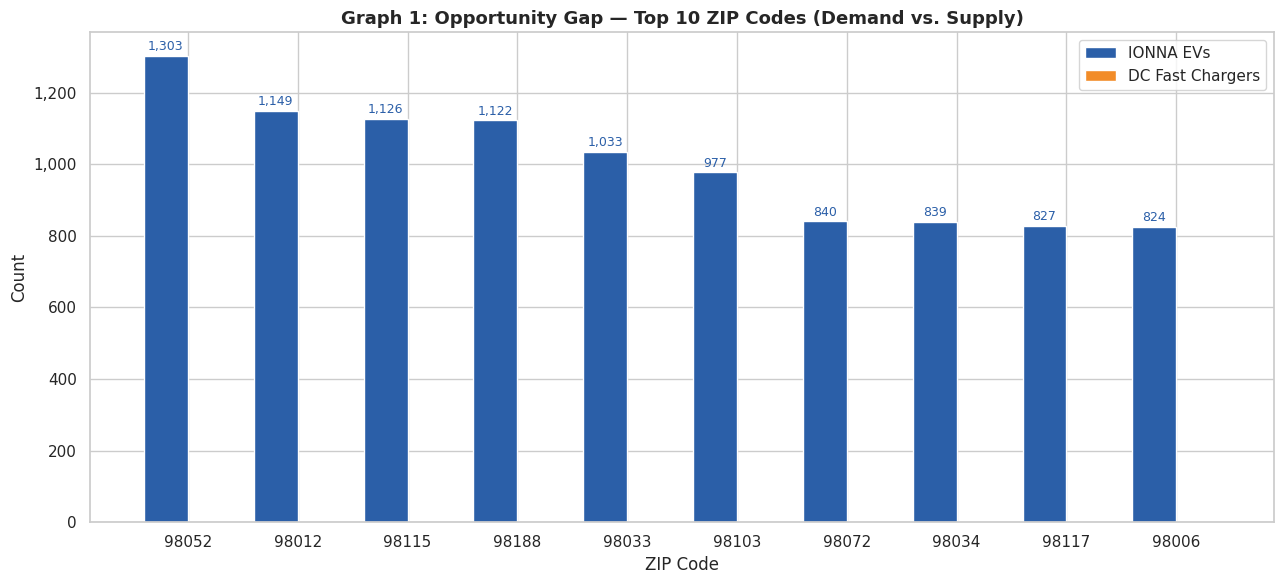

In [11]:
#  6: Graph 1 — The Opportunity Gap
top10 = merged.nlargest(10, 'opportunity_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top10))
bars_ev  = ax.bar(x - 0.2, top10['ionna_ev_count'], 0.4, label='IONNA EVs',        color='#2B5FA8')
bars_chg = ax.bar(x + 0.2, top10['dc_fast_total'],  0.4, label='DC Fast Chargers', color='#F28C28')
ax.set_xticks(x)
ax.set_xticklabels(top10['postal_code'], fontsize=11)
ax.set_xlabel('ZIP Code', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Graph 1: Opportunity Gap — Top 10 ZIP Codes (Demand vs. Supply)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar in bars_ev:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color='#2B5FA8')
plt.tight_layout()
plt.savefig('graph1_opportunity_gap.png', dpi=150, bbox_inches='tight')
plt.show()

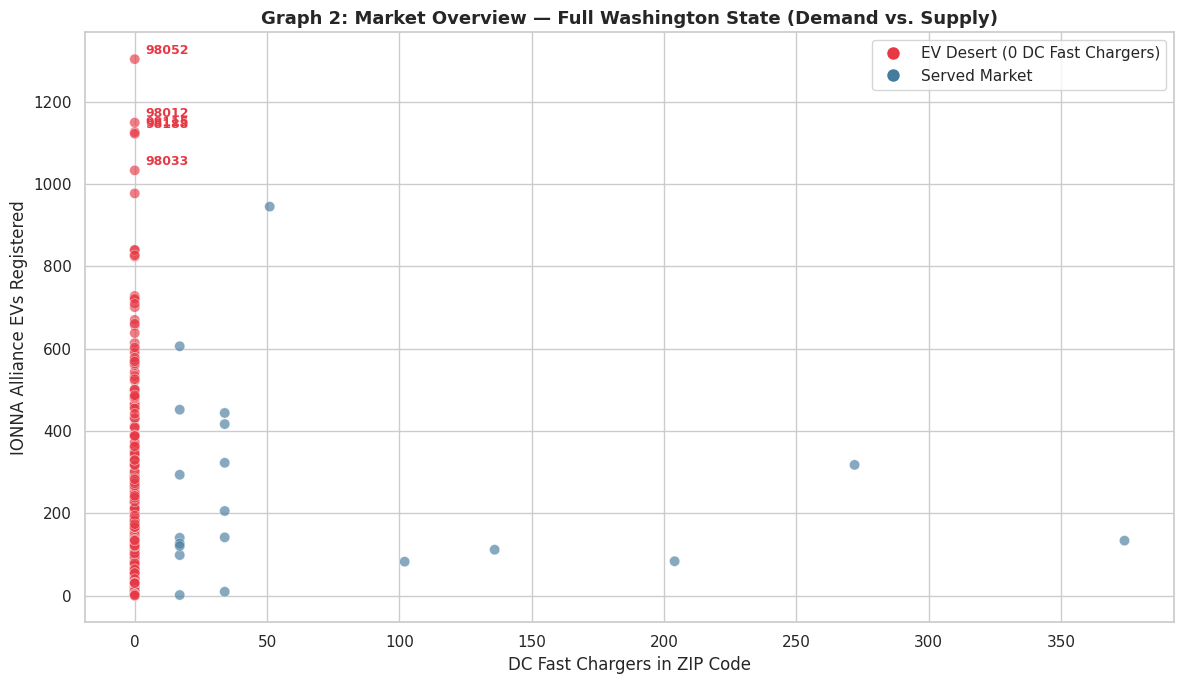

In [12]:
# 7: Graph 2 — Full Market Scatter
fig, ax = plt.subplots(figsize=(12, 7))
colors = merged['is_desert'].map({True: '#E63946', False: '#457B9D'})
ax.scatter(merged['dc_fast_total'], merged['ionna_ev_count'],
           c=colors, alpha=0.65, s=55, edgecolors='white', linewidths=0.4)
for _, row in top10.head(5).iterrows():
    ax.annotate(row['postal_code'],
                xy=(row['dc_fast_total'], row['ionna_ev_count']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, color='#E63946', fontweight='bold')
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E63946', markersize=10, label='EV Desert (0 DC Fast Chargers)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#457B9D', markersize=10, label='Served Market'),
]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_xlabel('DC Fast Chargers in ZIP Code', fontsize=12)
ax.set_ylabel('IONNA Alliance EVs Registered', fontsize=12)
ax.set_title('Graph 2: Market Overview — Full Washington State (Demand vs. Supply)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph2_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()


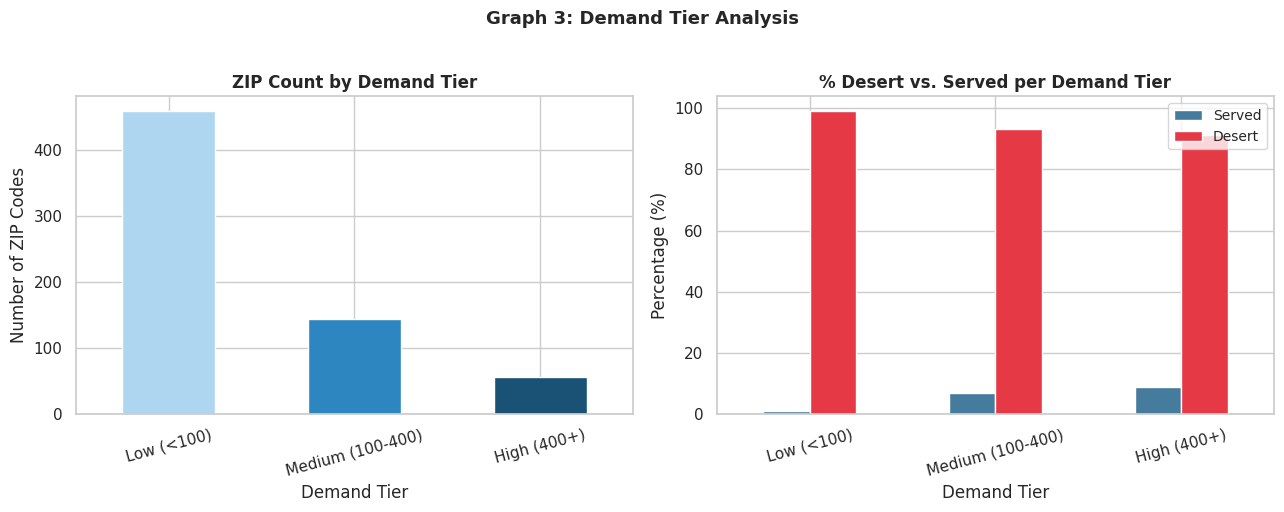

In [13]:
#  8: Graph 3 — Demand Tier Breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_counts = merged['demand_tier'].value_counts().sort_index()
tier_counts.plot(kind='bar', ax=axes[0], color=['#AED6F1','#2E86C1','#1A5276'], edgecolor='white')
axes[0].set_title('ZIP Count by Demand Tier', fontweight='bold')
axes[0].set_xlabel('Demand Tier')
axes[0].set_ylabel('Number of ZIP Codes')
axes[0].tick_params(axis='x', rotation=15)

tier_desert = merged.groupby(['demand_tier','is_desert']).size().unstack(fill_value=0)
tier_desert_pct = tier_desert.div(tier_desert.sum(axis=1), axis=0) * 100
tier_desert_pct.plot(kind='bar', ax=axes[1], color=['#457B9D','#E63946'], edgecolor='white')
axes[1].set_title('% Desert vs. Served per Demand Tier', fontweight='bold')
axes[1].set_xlabel('Demand Tier')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Served','Desert'], fontsize=10)
axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('Graph 3: Demand Tier Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph3_demand_tiers.png', dpi=150, bbox_inches='tight')
plt.show()


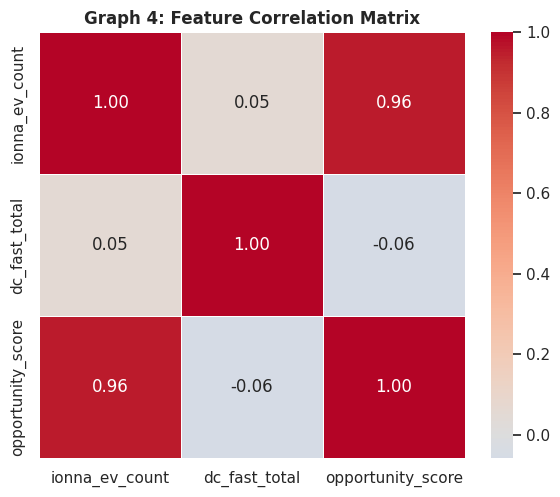

In [14]:
# 9: Graph 4 — Correlation Heatmap
corr_cols = ['ionna_ev_count', 'dc_fast_total', 'opportunity_score']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(merged[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Graph 4: Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('graph4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
#  10: Summary & Export
print('=' * 55)
print('  EDA SUMMARY — IONNA WA Charging Desert Analysis')
print('=' * 55)
print(f'Total IONNA-brand ZIP codes analyzed : {len(merged):,}')
print(f'Desert ZIPs (0 DC fast chargers)     : {merged["is_desert"].sum():,}')
print(f'Desert % of all IONNA ZIPs           : {merged["is_desert"].mean()*100:.1f}%')
print()
print('Top 5 Priority ZIP Codes:')
top5 = merged.nlargest(5, 'opportunity_score')[['postal_code','ionna_ev_count','dc_fast_total','opportunity_score']]
print(top5.to_string(index=False))
print()
merged.to_csv('wa_ionna_clean.csv', index=False)
print('Clean dataset saved: wa_ionna_clean.csv')
print('Ready for: Modeling_IONNA_Predictive')

  EDA SUMMARY — IONNA WA Charging Desert Analysis
Total IONNA-brand ZIP codes analyzed : 660
Desert ZIPs (0 DC fast chargers)     : 640
Desert % of all IONNA ZIPs           : 97.0%

Top 5 Priority ZIP Codes:
postal_code  ionna_ev_count  dc_fast_total  opportunity_score
      98052            1303              0             1303.0
      98012            1149              0             1149.0
      98115            1126              0             1126.0
      98188            1122              0             1122.0
      98033            1033              0             1033.0

Clean dataset saved: wa_ionna_clean.csv
Ready for: Modeling_IONNA_Predictive
